In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Output/df_featured.csv', encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,...,Rating color,Rating text,Votes,n_outlets,Is Chain,Is Rated,Is NCR,Cuisines Count,Primary Cuisine,Log_Votes
0,3400025,Jahanpanah,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,"North Indian, Mughlai",850,...,Yellow,Good,140,1,False,True,False,2,North Indian,4.948760
1,3400341,Rangrezz Restaurant,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,"North Indian, Mughlai",700,...,Yellow,Good,71,1,False,True,False,2,North Indian,4.276666
2,3400005,Time2Eat - Mama Chicken,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra Cantt,"Agra Cantt, Agra",78.011608,27.160832,North Indian,500,...,Yellow,Good,94,1,False,True,False,1,North Indian,4.553877
3,3400021,Chokho Jeeman Marwari Jain Bhojanalya,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",Civil Lines,"Civil Lines, Agra",77.998092,27.195928,Rajasthani,400,...,Green,Very Good,87,1,False,True,False,1,Rajasthani,4.477337
4,3400017,Pinch Of Spice,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,"North Indian, Chinese, Mughlai",1000,...,Green,Very Good,177,1,False,True,False,3,North Indian,5.181784


In [3]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'n_outlets', 'Is Chain', 'Is Rated', 'Is NCR',
       'Cuisines Count', 'Primary Cuisine', 'Log_Votes'],
      dtype='object')

# Univariate Analysis:

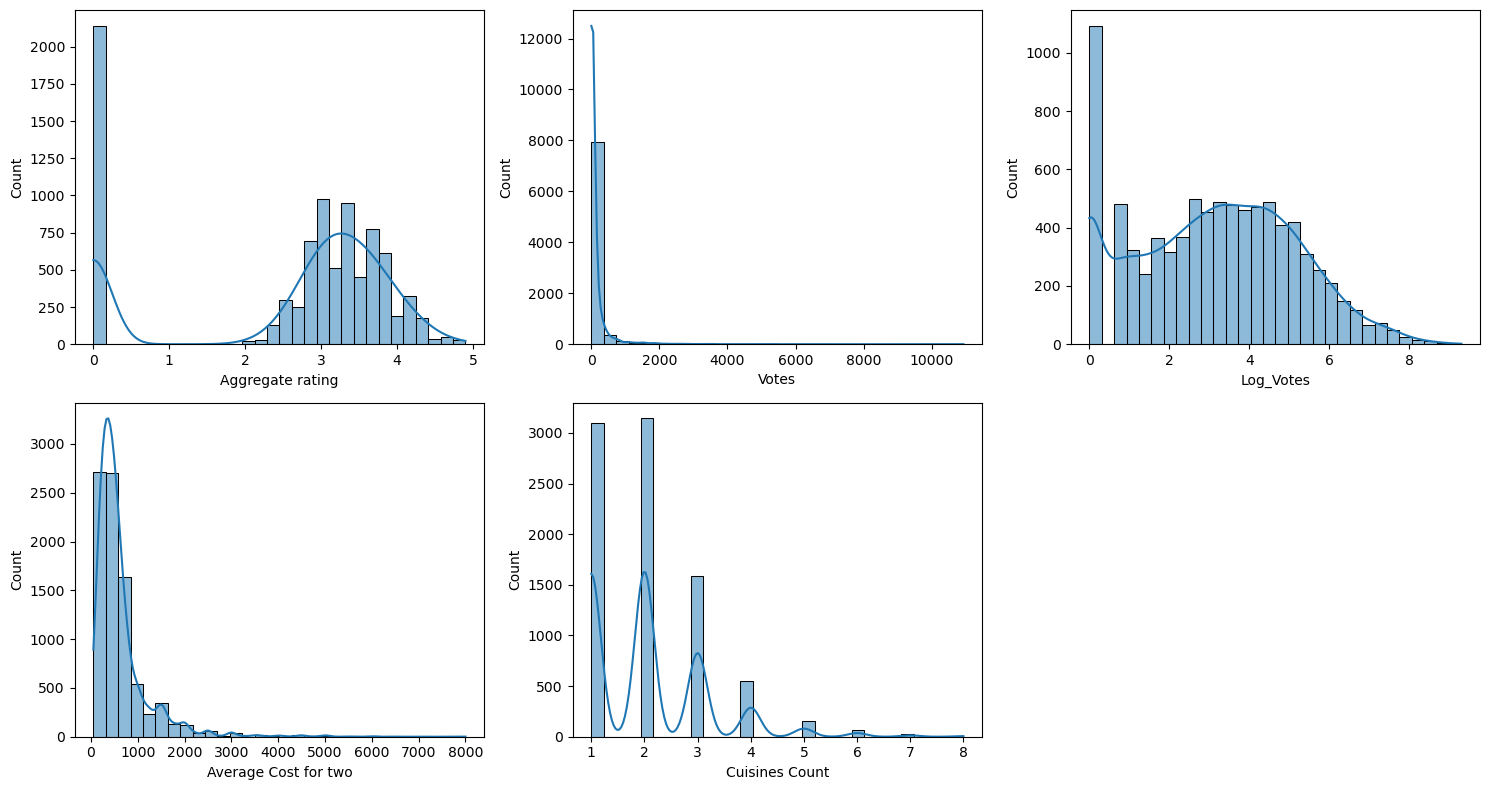

In [4]:
# Numerical columns: ['Aggreagate rating', 'Votes', 'Log_Votes', 'Average Cost for two', 'Cuisines Count']
# Ploting histogram+KDE+boxplot for the above numerical columns

numerical_columns=['Aggregate rating', 'Votes', 'Log_Votes', 'Average Cost for two', 'Cuisines Count']
fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, cols in enumerate(numerical_columns):
    row=i//3
    c=i%3
    sns.histplot(df[cols], kde=True, ax=axes[row][c], bins=30)
    plt.title(cols)
fig.delaxes(ax=axes[1][2])
plt.tight_layout()
plt.show()
    

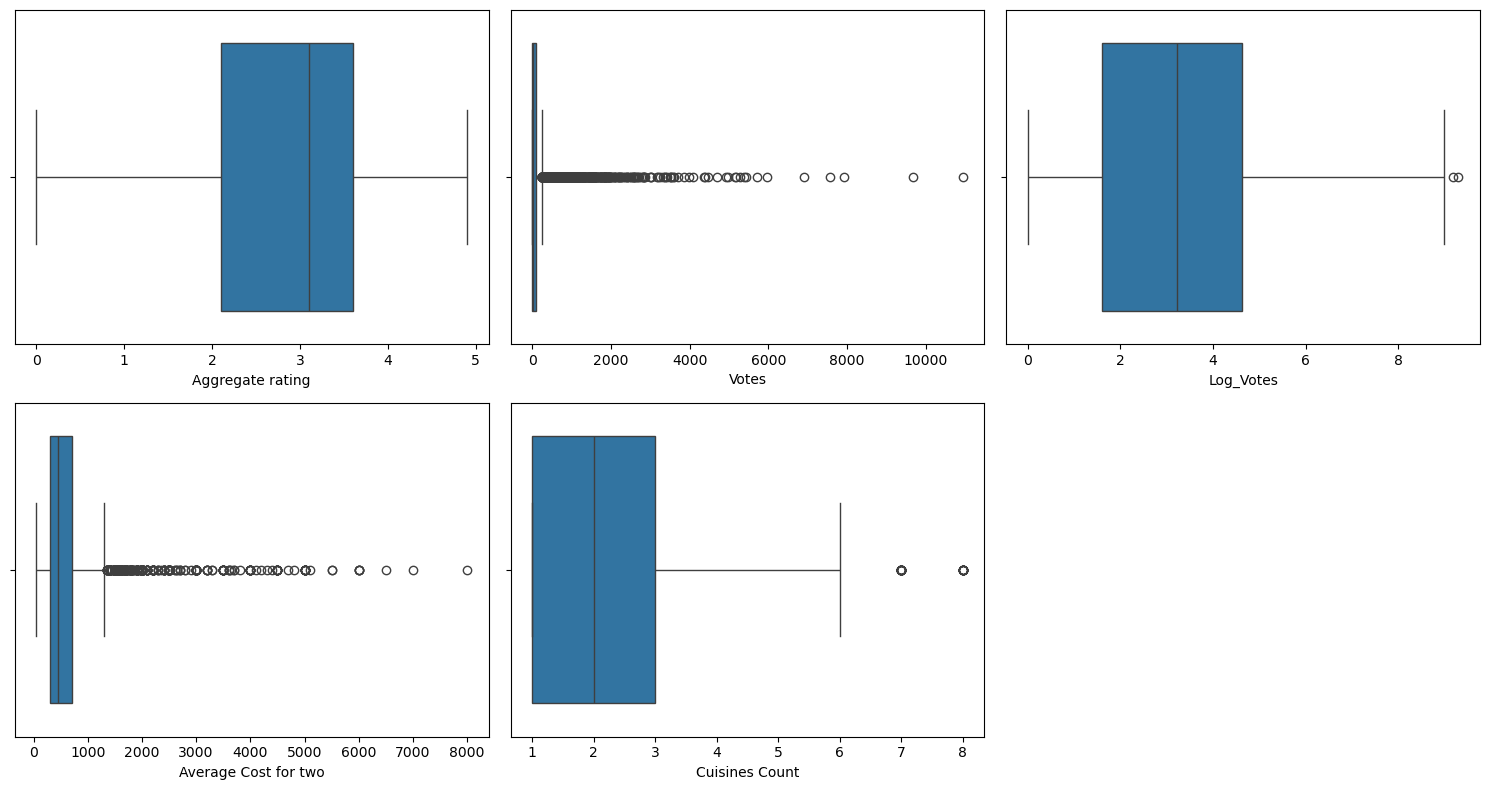

In [5]:
#boxplot:
fig, axes_box=plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, cols in enumerate(numerical_columns):
    row=i//3
    col=i%3
    sns.boxplot(x=df[cols], ax=axes_box[row][col])
    plt.title(cols)

fig.delaxes(ax=axes_box[1][2])
plt.tight_layout()
plt.show()

### Observation:
- **Aggregate rating** is bimodal, not simply skewed: 2,139 rows (24.7%) sit at exactly 0 (mean 2.52 vs median 3.10, skew -0.88), which is the *"Not rated"* flag encoded as a number (`Rating text == "Not rated"`), not restaurants that were genuinely rated poorly. Once separated by `Is Rated`, the real rating cluster is roughly bell-shaped between ~2.5-4.5. IQR flags 0 outliers here only because both populations sit inside the bounded 0-4.9 rating scale.
- **Votes** is extremely right-skewed (skew 9.65, kurtosis 144.9) - mean (137.3) is far above median (24.0), pulled up by a small number of viral restaurants with thousands of votes. IQR flags 12.1% of rows (1,048) as outliers, which mostly reflects that IQR fences don't suit this shape of data rather than 1,048 genuine anomalies.
- **Log_Votes** confirms the `log1p` transform worked: skew drops from 9.65 to 0.07 (near-symmetric), kurtosis flattens from 144.9 to -0.77, and IQR outliers collapse from 1,048 to 2. Use this column for correlation/modeling instead of raw `Votes`.
- **Average Cost for two** is right-skewed (skew 3.59, kurtosis 20.4) with 813 IQR outliers (9.4%) - matches the premium-restaurant segment already investigated in `Data_cleaning.ipynb` and deliberately **kept** (Delhi NCR fine dining, higher avg rating).
- **Cuisines Count** is close to well-behaved: mild right skew (1.34), most restaurants offer 1-3 cuisines (median 2), only 38 IQR outliers (0.4%).
- **Action item:** from here on, any analysis involving `Aggregate rating` must run on `df[df["Is Rated"]]`, not the full `df` - otherwise the 24.7% "not rated" spike will contaminate every correlation and comparison.

In [6]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'n_outlets', 'Is Chain', 'Is Rated', 'Is NCR',
       'Cuisines Count', 'Primary Cuisine', 'Log_Votes'],
      dtype='object')

In [7]:
# Categorical columns: ['Price Range', 'Has Table booking', 'Has Online delivery', 'is Chain', 'Primary Cuisine', 'Is NCR']
# Grouping the catogorical columns according to their types:
binary_ordinal_columns=['Has Table booking', 'Has Online delivery', 'Is Chain', 'Is NCR', 'Is Rated', 'Price range']
high_cardinality_columns=['Primary Cuisine', 'City', 'Locality']

#Frequency+Proportion for the binary/ordinal columns
for cols in binary_ordinal_columns:
    counts=df[cols].value_counts().sort_index()
    percentages=(df[cols].value_counts(normalize=True).sort_index()*100).round(2)
    summary=pd.DataFrame({'count':counts, 'percentage':percentages})
    print(f"---{cols}---")
    print(summary)
    print()

---Has Table booking---
                   count  percentage
Has Table booking                   
0                   7532       87.15
1                   1111       12.85

---Has Online delivery---
                     count  percentage
Has Online delivery                   
0                     6220       71.97
1                     2423       28.03

---Is Chain---
          count  percentage
Is Chain                   
False      5888       68.12
True       2755       31.88

---Is NCR---
        count  percentage
Is NCR                   
False     696        8.05
True     7947       91.95

---Is Rated---
          count  percentage
Is Rated                   
False      2139       24.75
True       6504       75.25

---Price range---
             count  percentage
Price range                   
1             4286       49.59
2             2858       33.07
3             1111       12.85
4              388        4.49



In [8]:
# Cardinality and cumulative coverage for high cardinality columns
# For high cardinality columns: check the total cardinality, top-N coverage, and the long tail
for cols in high_cardinality_columns:
    freq=(df[cols].value_counts(normalize=True)*100).round(2)
    cummulative=freq.cumsum()
    rare_counts=(df[cols].value_counts()<10).sum()

    print(f"---{cols}---")
    print(f"Unique Categories: {df[cols].nunique()}")
    print(f"Top 15 categories cover: {cummulative.iloc[14]:.2f}% of rows")
    print(f"Catogories with less than 10 rows: {rare_counts} of {df[cols].nunique()}")

---Primary Cuisine---
Unique Categories: 74
Top 15 categories cover: 88.59% of rows
Catogories with less than 10 rows: 37 of 74
---City---
Unique Categories: 43
Top 15 categories cover: 94.30% of rows
Catogories with less than 10 rows: 3 of 43
---Locality---
Unique Categories: 783
Top 15 categories cover: 14.66% of rows
Catogories with less than 10 rows: 589 of 783


### Observation:
- **Binary/ordinal columns:** `Has Table booking` (87.15% No) and `Has Online delivery` (71.97% No) are both imbalanced minority features; `Is Chain` (31.88% chain) is a substantial, trustworthy segment. `Is NCR` (91.95% NCR) and `Is Rated` (75.25% rated) both match numbers already established earlier in the project - a working sanity check, not a coincidence.
- **`Price range`** shows a clean monotonic decline across tiers (49.59% -> 33.07% -> 12.85% -> 4.49%) - the market is dominated by budget dining, and each step up in price tier holds a shrinking share.
- **`Primary Cuisine` (74 categories) and `City` (43 categories) are concentrated:** their top 15 categories cover 88.59% and 94.30% of rows respectively, so a "top 15 + Other" chart will represent them honestly.
- **`Locality` (783 categories) is fragmented, not concentrated:** its top 15 cover only 14.66% of rows, and 589 of 783 localities (75%) have fewer than 10 rows. A top-N chart here would misleadingly claim to summarize the column while representing a small slice of it - `Locality` needs a minimum-row filter (plan.md suggests >=30) rather than a top-N plot, and any groupby statistic on raw `Locality` should be treated as unreliable for the long tail.
- **Action item:** use `City`/`Is NCR` for geography in charts and comparisons; reserve `Locality` for filtered, fine-grained analysis only (>=30 rows per locality), not for a general countplot.

## Categorical columns: visualizing the distributions

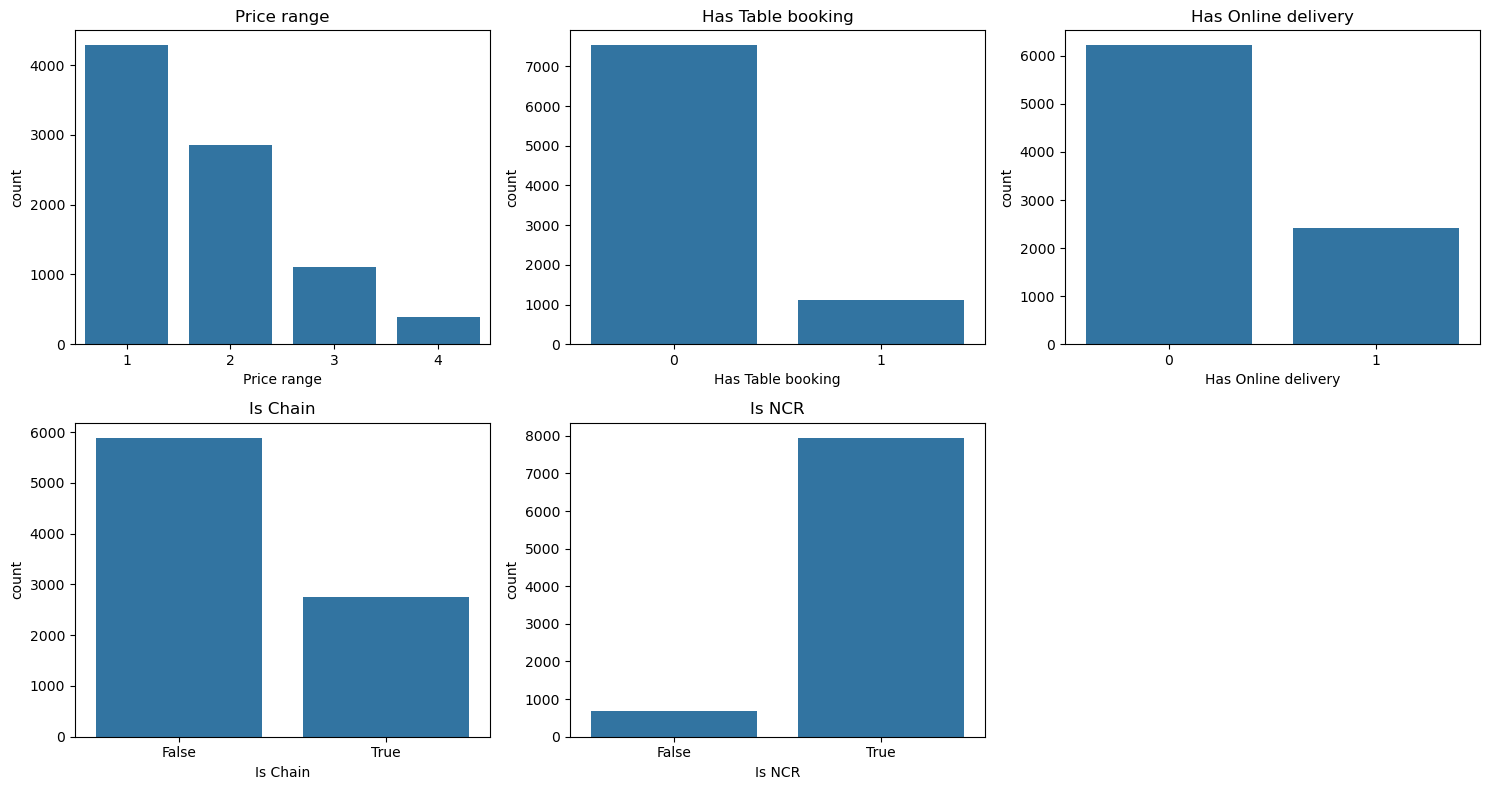

In [9]:
# Countplots for binary/ordinal categorical columns, kept in natural order
plot_order = {
    'Price range': [1, 2, 3, 4],
    'Has Table booking': [0, 1],
    'Has Online delivery': [0, 1],
    'Is Chain': [False, True],
    'Is NCR': [False, True],
}
countplot_columns = list(plot_order.keys())

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, cols in enumerate(countplot_columns):
    row = i // 3
    col = i % 3
    sns.countplot(x=df[cols], order=plot_order[cols], ax=axes[row][col])
    axes[row][col].set_title(cols)
fig.delaxes(axes[1][2])
plt.tight_layout()
plt.show()

### Observation:
- **`Price range`** shows a clear declining bar pattern (tier 1 tallest, tier 4 shortest) - visually confirms the 49.59% -> 4.49% monotonic decline already found in the frequency table: this market is dominated by budget dining.
- **`Has Table booking`** and **`Has Online delivery`** both show a large "No" bar dwarfing "Yes" - table booking especially so (87.15% No).
- **`Is Chain`** is the most balanced of the group (68/32) - a real, sizeable minority rather than a rare edge case.
- **`Is NCR`** shows an overwhelming majority bar for "True" (91.95%) - visually reinforces that this dataset is a Delhi-NCR dataset with a thin national tail, not a nationally-representative sample.

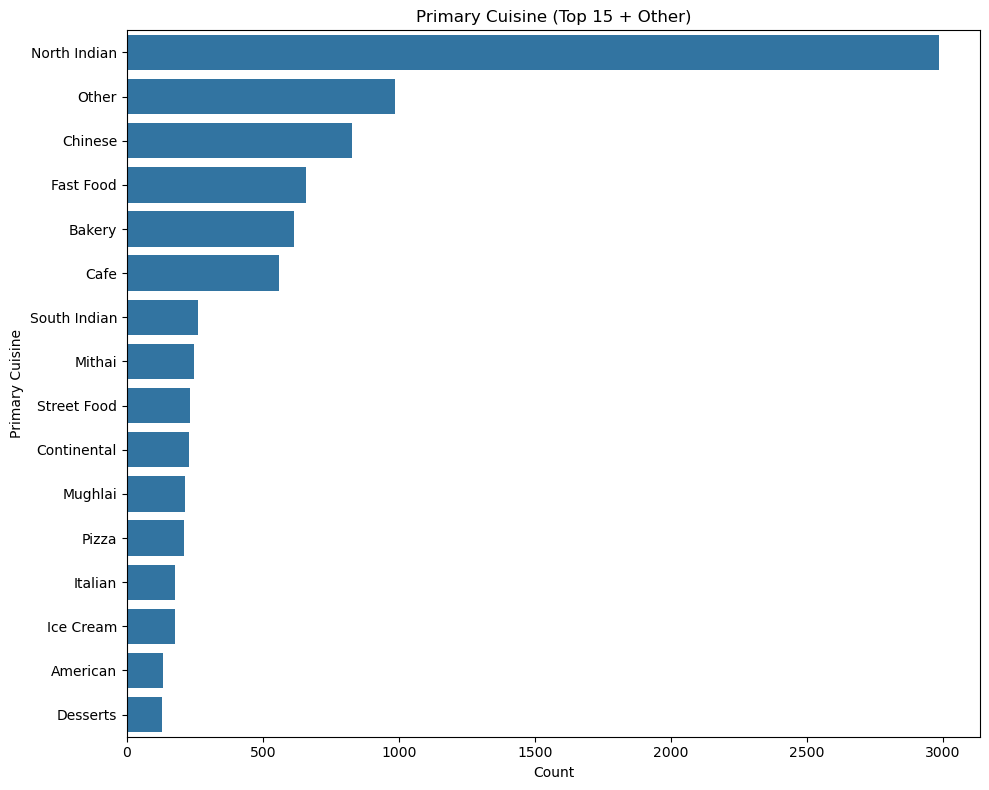

In [10]:
# Top 15 Primary Cuisines by frequency (covers 88.59% of rows) -- the rest bucketed as 'Other'
top_cuisines = df['Primary Cuisine'].value_counts().head(15).index
cuisine_plot_data = df['Primary Cuisine'].where(df['Primary Cuisine'].isin(top_cuisines), 'Other')

plt.figure(figsize=(10, 8))
sns.countplot(y=cuisine_plot_data, order=cuisine_plot_data.value_counts().index)
plt.title('Primary Cuisine (Top 15 + Other)')
plt.xlabel('Count')
plt.ylabel('Primary Cuisine')
plt.tight_layout()
plt.show()

### Observation:
- **`North Indian` dominates completely** - 2,988 restaurants (34.6% of all 8,643), more than 3.5x the #2 cuisine (`Chinese`, 827, 9.6%). This isn't surprising given the NCR concentration, but it means `North Indian` will anchor almost every cuisine-level comparison downstream - differences between other cuisines are being compared against a very large, very central baseline.
- `Chinese`, `Fast Food`, `Bakery`, `Cafe` form a second tier (500-850 rows each) - these are the cuisines with enough volume to trust group-level statistics on.
- The `Other` bucket (11.41% of rows spread across 59 cuisines) confirms the earlier top-15 coverage number - it's a real but manageable "everything else" category, not a hidden majority.

In [11]:
# Stats table: mean, median, skew, kurtosis, and IQR-outlier count per numeric column
stats_rows = []
for col in numerical_columns:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((s < lb) | (s > ub)).sum()
    stats_rows.append({
        'column': col,
        'mean': round(s.mean(), 2),
        'median': round(s.median(), 2),
        'skew': round(s.skew(), 2),
        'kurtosis': round(s.kurt(), 2),
        'iqr_outliers': outliers,
        'pct_outliers': round(outliers / len(s) * 100, 2),
    })
stats_table = pd.DataFrame(stats_rows).set_index('column')
stats_table

,mean,median,skew,kurtosis,iqr_outliers,pct_outliers
column,,,,,,
Aggregate rating,2.52,3.10,-0.88,-0.82,0,0.00
Votes,137.27,24.00,9.65,144.91,1048,12.13
Log_Votes,3.14,3.22,0.07,-0.77,2,0.02
Average Cost for two,624.02,450.00,3.59,20.38,813,9.41
Cuisines Count,2.06,2.00,1.34,2.67,38,0.44


### Observation:
This table is the numeric backbone of the univariate section above - it's what the histogram/boxplot/countplot grids were drawn from:
- `Aggregate rating`: mean (2.52) sits well below median (3.10) - the signature of the zero-rating spike mixed into an otherwise centered distribution, not genuine left skew.
- `Votes`: skew 9.65, kurtosis 144.9, 1,048 IQR outliers (12.1%) - extreme right tail; `Log_Votes` is the column to actually use going forward (skew 0.07, 2 outliers).
- `Average Cost for two`: skew 3.59, 813 IQR outliers (9.4%) - the already-investigated, deliberately-kept premium segment.
- `Cuisines Count`: closest to well-behaved (skew 1.34, 38 outliers, 0.4%).

In [12]:
# Rated vs Unrated -- explicit comparison, not a footnote
rated_vs_unrated = df.groupby('Is Rated').agg(
    n=('Restaurant ID', 'count'),
    mean_cost=('Average Cost for two', 'mean'),
    mean_price_range=('Price range', 'mean'),
    pct_chain=('Is Chain', 'mean'),
    pct_online_delivery=('Has Online delivery', 'mean'),
    pct_table_booking=('Has Table booking', 'mean'),
    pct_ncr=('Is NCR', 'mean'),
).round(3)
rated_vs_unrated

,n,mean_cost,mean_price_range,pct_chain,pct_online_delivery,pct_table_booking,pct_ncr
Is Rated,,,,,,,
False,2139,341.599,1.231,0.217,0.045,0.022,1.000
True,6504,716.900,1.884,0.352,0.358,0.164,0.893


### Observation:
Unrated restaurants (2,139 rows, 24.7% of the dataset) are not a random slice missing a label - they are a **systematically different, cold-start segment**:
- **Cheaper**: mean cost ₹342 vs ₹717 for rated restaurants, and a lower mean price range (1.23 vs 1.88).
- **Far less likely to offer online delivery** (4.5% vs 35.8%) or table booking (2.2% vs 16.4%).
- **Less likely to be a chain** (21.7% vs 35.2%) - chains get rated faster, presumably from built-in brand traffic.
- **100% located in NCR** (`Is NCR` mean = 1.000) - every single unrated restaurant in this dataset is in the Delhi-NCR cluster; by contrast only 89.3% of *rated* restaurants are in NCR. In other words, **all restaurants outside NCR have been rated** - the "not rated" problem is entirely an NCR phenomenon, most likely small/informal/newly-listed places in a saturated market that haven't accumulated reviews yet.

This profile - cheap, non-chain, no delivery, no booking, NCR-only - is exactly the feature signature Phase 5B's "which restaurants never get rated" classifier will need to learn.

# Bivariate Analysis (target = Aggregate rating)

**Every chart below that involves `Aggregate rating` uses `df_rated` (rating > 0).** The 24.7% "not rated" rows encoded as rating 0 are not part of the rating distribution and would distort every relationship shown here (see the earlier §0.1 finding).

In [13]:
df_rated = df[df['Is Rated']].copy()
print('df_rated shape:', df_rated.shape)

df_rated shape: (6504, 24)


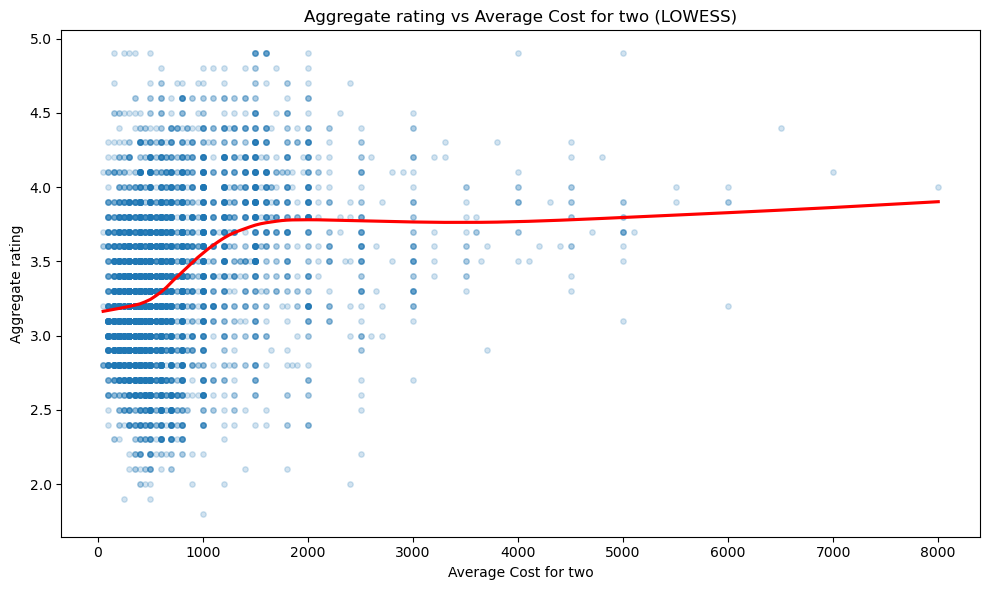

In [14]:
# Aggregate rating vs Average Cost for two -- scatter + LOWESS (the relationship is non-linear)
plt.figure(figsize=(10, 6))
sns.regplot(x='Average Cost for two', y='Aggregate rating', data=df_rated, lowess=True,
            scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'})
plt.title('Aggregate rating vs Average Cost for two (LOWESS)')
plt.tight_layout()
plt.show()

### Observation:
The LOWESS curve rises but **flattens out** as cost increases, instead of climbing in a straight line - rating gains from spending more taper off past the mid-price range. Pearson correlation is only **0.313** (Spearman 0.332, similar - so it's not just a nonlinearity issue masking a stronger monotonic trend). Cost alone explains very little of rating - consistent with `plan.md`'s expectation of a modest R^2 for an actionable model. There's also a visibly wide vertical spread of ratings at every cost level - cheap restaurants can be excellent, expensive ones can be mediocre.

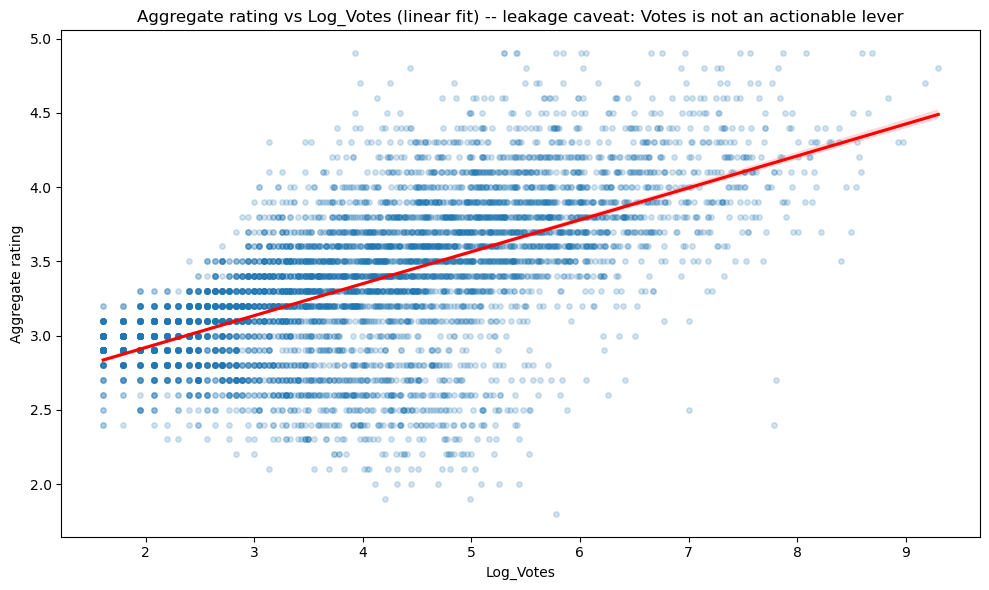

In [15]:
# Aggregate rating vs Log_Votes -- scatter + regression
# Caveat: Votes is measured *simultaneously* with rating (popularity and rating co-evolve),
# so this relationship is descriptive, not something an owner can act on (see plan.md leakage note).
plt.figure(figsize=(10, 6))
sns.regplot(x='Log_Votes', y='Aggregate rating', data=df_rated,
            scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'})
plt.title('Aggregate rating vs Log_Votes (linear fit) -- leakage caveat: Votes is not an actionable lever')
plt.tight_layout()
plt.show()

### Observation:
`Log_Votes` is the strongest bivariate relationship with rating found so far: Pearson **0.625**, Spearman **0.651** - clearly linear-ish and much tighter than cost. But this is **not a lever a restaurant owner can pull** - votes and rating are two outputs of the same underlying popularity/quality process, measured at the same point in time, not a cause of rating. Any model that wants to say "what should this restaurant *do*" (Phase 5A's "actionable" framing) must drop `Votes`/`Log_Votes`; any model that only wants to *describe* what highly-rated restaurants look like can keep it.

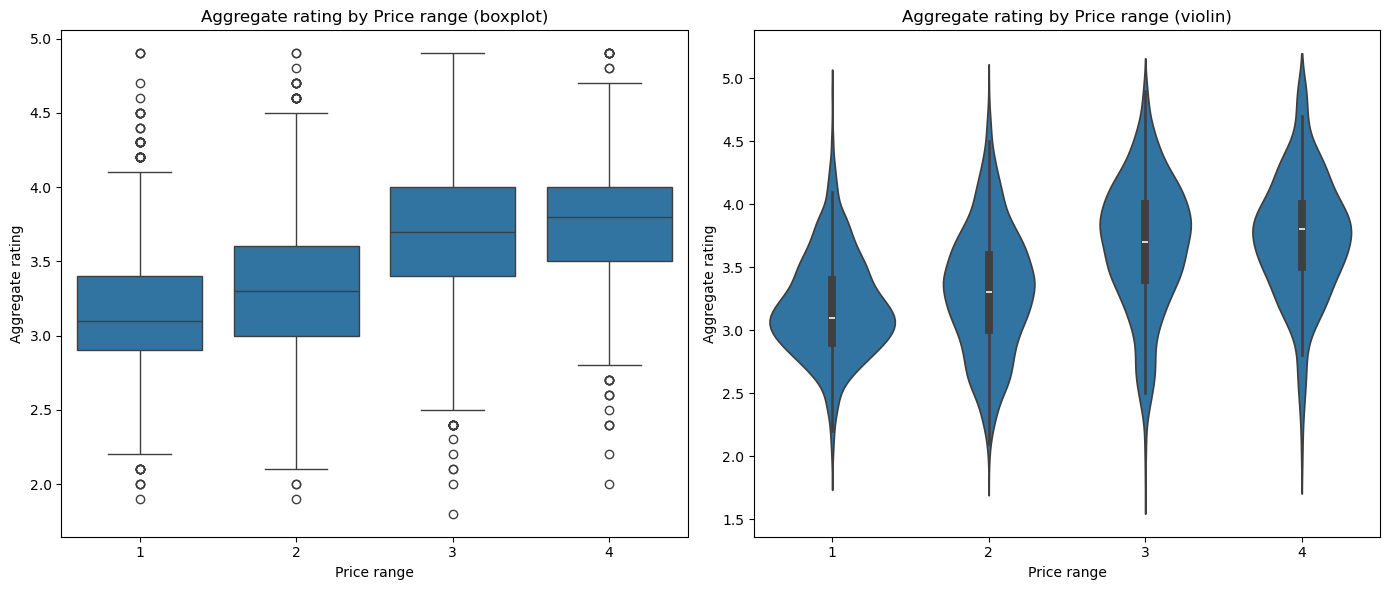

In [16]:
# Aggregate rating vs Price range -- boxplot + violin
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='Price range', y='Aggregate rating', data=df_rated, ax=axes[0])
axes[0].set_title('Aggregate rating by Price range (boxplot)')
sns.violinplot(x='Price range', y='Aggregate rating', data=df_rated, ax=axes[1])
axes[1].set_title('Aggregate rating by Price range (violin)')
plt.tight_layout()
plt.show()

### Observation:
Median rating rises with each price tier: **3.1 -> 3.3 -> 3.7 -> 3.8** (tiers 1 to 4), and the violin shapes get visibly narrower and shift upward at higher tiers - expensive restaurants aren't just rated higher on average, they're also *more consistently* rated higher (less spread). Remember `Price range` and `Average Cost for two` are Spearman ρ=0.91 redundant (`plan.md` §0.4) - this chart and the cost-vs-rating LOWESS chart above are largely telling the same story from two angles, not two independent findings.

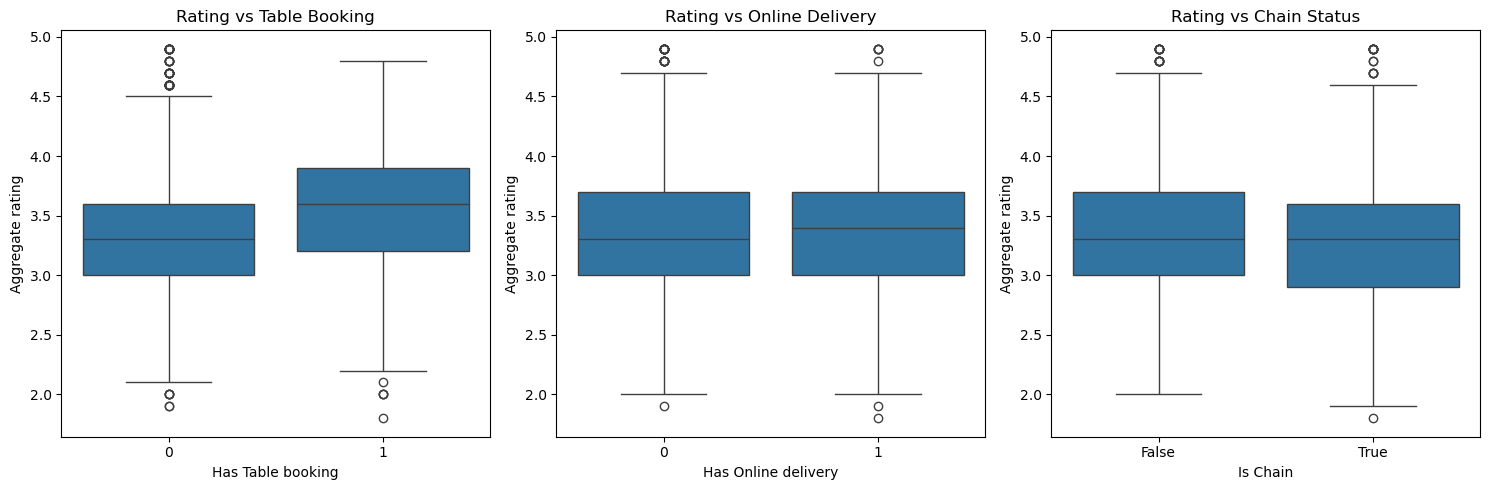

In [17]:
# Aggregate rating vs Has Table booking / Has Online delivery / Is Chain -- grouped boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Has Table booking', y='Aggregate rating', data=df_rated, ax=axes[0])
axes[0].set_title('Rating vs Table Booking')
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df_rated, ax=axes[1])
axes[1].set_title('Rating vs Online Delivery')
sns.boxplot(x='Is Chain', y='Aggregate rating', data=df_rated, ax=axes[2])
axes[2].set_title('Rating vs Chain Status')
plt.tight_layout()
plt.show()

### Observation:
On `df_rated`, the differences are much smaller than they looked on the unfiltered data:
- **Table booking**: mean rating 3.55 (Yes) vs 3.31 (No) - the largest gap of the three, plausibly because booking-enabled restaurants tend to be higher-tier venues (correlated with cost/price range).
- **Online delivery**: mean rating 3.37 (Yes) vs 3.34 (No) - essentially flat. This directly reproduces the `plan.md` §0.1 headline finding: the "online delivery -> higher rating" signal (correlation 0.302 on unfiltered data) all but disappears once unrated rows are excluded - it was ~90% an artifact of unrated restaurants also having no delivery.
- **Chain status**: mean rating 3.30 (chain) vs 3.38 (independent) - chains rate *slightly lower*, not higher; being a chain is not a rating advantage here.

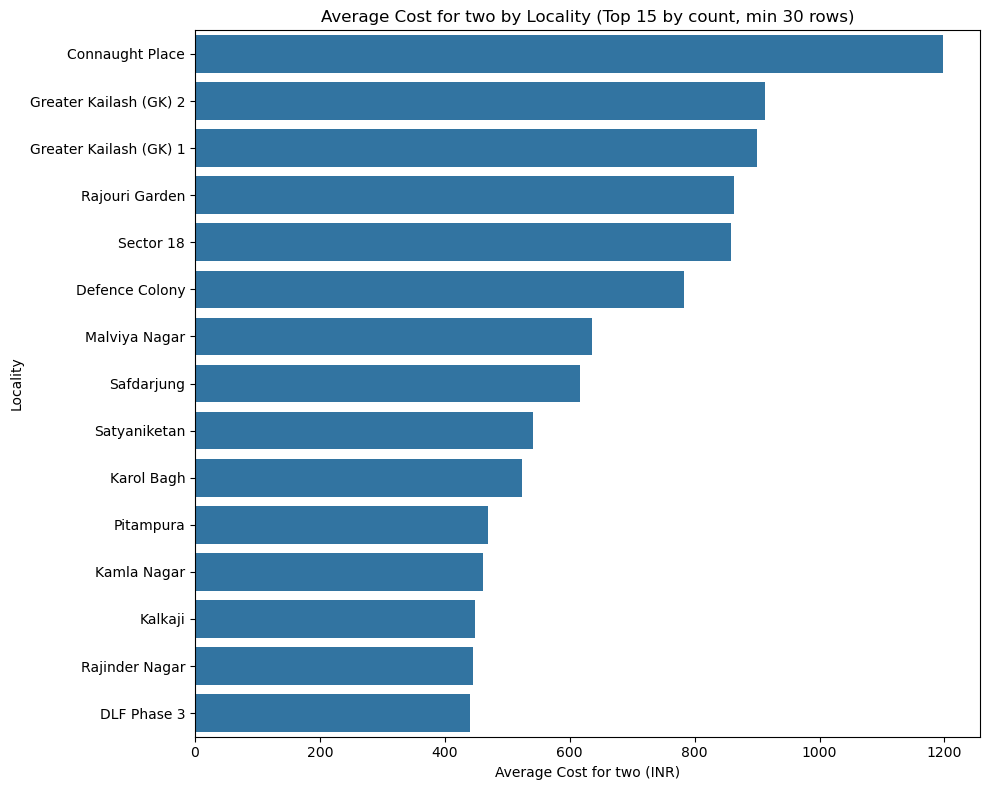

In [18]:
# Average Cost for two vs Locality (top 15 by count, min 30 rows) -- horizontal bar
locality_counts = df_rated['Locality'].value_counts()
top_localities = locality_counts[locality_counts >= 30].head(15).index
locality_cost = (df_rated[df_rated['Locality'].isin(top_localities)]
                 .groupby('Locality')['Average Cost for two']
                 .mean()
                 .sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.barplot(x=locality_cost.values, y=locality_cost.index, orient='h')
plt.title('Average Cost for two by Locality (Top 15 by count, min 30 rows)')
plt.xlabel('Average Cost for two (INR)')
plt.tight_layout()
plt.show()

### Observation:
Cost varies by roughly **2.7x** across these top localities: `Connaught Place` (₹1,197 mean) is the most expensive, more than double the cheapest locality shown, `DLF Phase 3` (₹441). This is a much bigger spread than the NCR-vs-rest split alone would suggest (see the NCR comparison below) - locality is a genuinely finer-grained pricing signal than city, which is exactly why `plan.md` keeps `Locality` (filtered to >=30 rows) for granularity rather than relying on `City` alone.

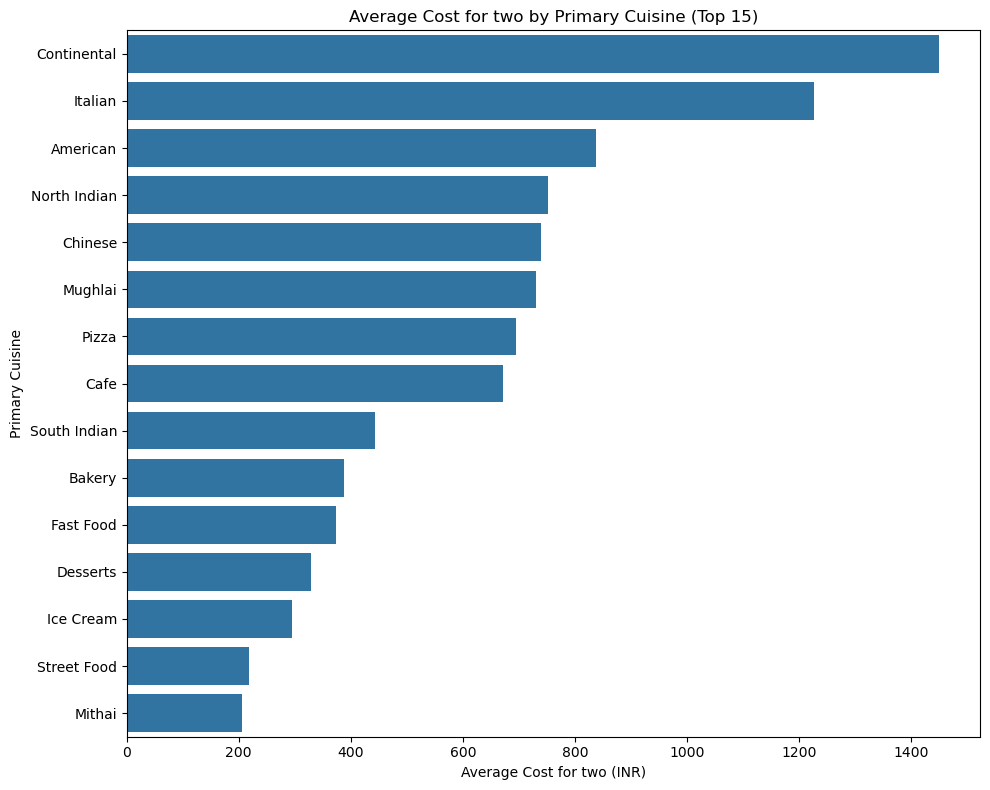

In [19]:
# Average Cost for two vs Primary Cuisine (top 15) -- horizontal bar
cuisine_cost = (df_rated[df_rated['Primary Cuisine'].isin(top_cuisines)]
                .groupby('Primary Cuisine')['Average Cost for two']
                .mean()
                .sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.barplot(x=cuisine_cost.values, y=cuisine_cost.index, orient='h')
plt.title('Average Cost for two by Primary Cuisine (Top 15)')
plt.xlabel('Average Cost for two (INR)')
plt.tight_layout()
plt.show()

### Observation:
Cost spread by cuisine is even wider than by locality - **~7x** from cheapest to most expensive: `Continental` (₹1,451 mean) and `Italian` (₹1,227) sit far above `Mithai` (₹206) and `Street Food` (₹217). `North Indian`, despite dominating by volume (2,988 restaurants), sits mid-pack on price (₹751) - the most common cuisine is not the most expensive one, so cuisine popularity and cuisine price tier are separate signals worth keeping apart.

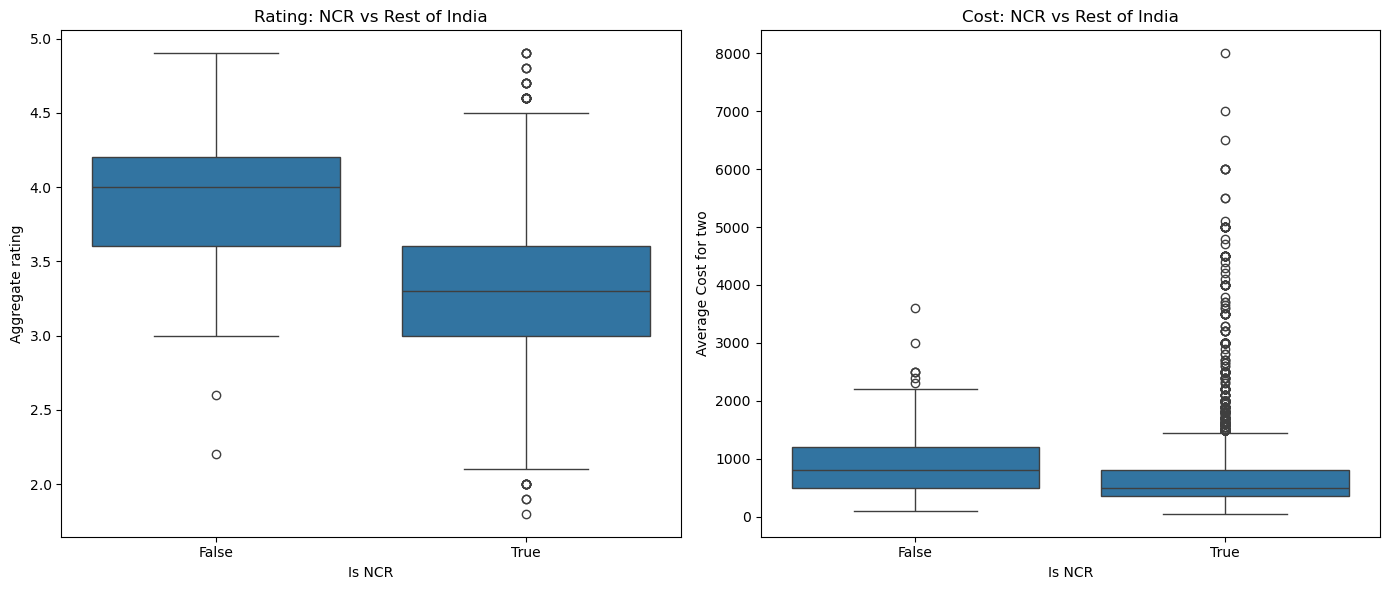

,n,mean_rating,median_rating,mean_cost
Is NCR,,,,
False,696,3.94,4.0,894.67
True,5808,3.28,3.3,695.60


In [20]:
# NCR vs Rest of India -- side-by-side comparison (replaces the old top-10-cities chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='Is NCR', y='Aggregate rating', data=df_rated, ax=axes[0])
axes[0].set_title('Rating: NCR vs Rest of India')
sns.boxplot(x='Is NCR', y='Average Cost for two', data=df_rated, ax=axes[1])
axes[1].set_title('Cost: NCR vs Rest of India')
plt.tight_layout()
plt.show()

ncr_comparison = df_rated.groupby('Is NCR').agg(
    n=('Restaurant ID', 'count'),
    mean_rating=('Aggregate rating', 'mean'),
    median_rating=('Aggregate rating', 'median'),
    mean_cost=('Average Cost for two', 'mean'),
).round(2)
ncr_comparison

### Observation:
This is a counter-intuitive result worth flagging clearly: restaurants **outside** NCR are both **higher rated** (mean 3.94 vs 3.28, median 4.0 vs 3.3) *and* **more expensive on average** (₹895 vs ₹696) than NCR restaurants, despite NCR being the volume center of the dataset. Two honest caveats before reading too much into this: (1) non-NCR is only 696 rated rows (10.7% of `df_rated`) spread across 38 cities - a much smaller, noisier sample than NCR's 5,808; (2) recall from the earlier finding that **100% of unrated restaurants are in NCR** - NCR's rated subset may be systematically pulled down because it's diluted with newer/thinner-track-record venues that only cross into "rated" once they've accumulated some criticism, while every non-NCR restaurant in the dataset already cleared that bar. This is a candidate for a formal significance test in Phase 4, not a conclusion yet.

# Multivariate Analysis

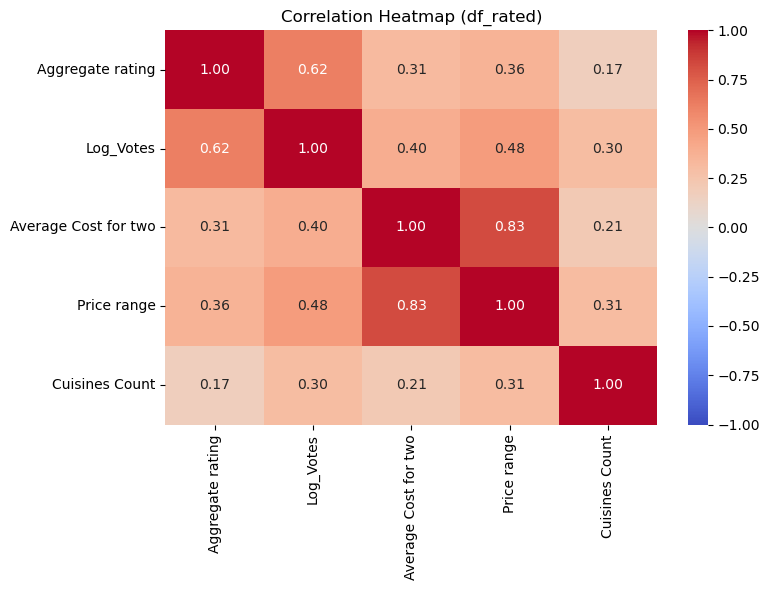

In [21]:
# Correlation heatmap -- Average Cost for two and Price range are ~0.83 correlated here
# (both included, but treated as one signal, not two independent features, per the ρ=0.91 finding)
corr_cols = ['Aggregate rating', 'Log_Votes', 'Average Cost for two', 'Price range', 'Cuisines Count']
corr_matrix = df_rated[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (df_rated)')
plt.tight_layout()
plt.show()

### Observation:
- `Log_Votes` is `Aggregate rating`'s strongest correlate (**0.63**) - but carries the leakage caveat already noted.
- `Average Cost for two` and `Price range` correlate at **0.83** with each other (the ρ=0.91 Spearman figure from `plan.md`, close to it in Pearson terms too) - clearly redundant; only one should enter a linear model at a time.
- `Cuisines Count` is the weakest correlate of rating (**0.17**) - offering more cuisines barely moves the needle on rating.
- No pair here is anywhere near collinear enough to be a modeling *problem* except the cost/price-range pair - that's the one redundancy this heatmap exists to catch.

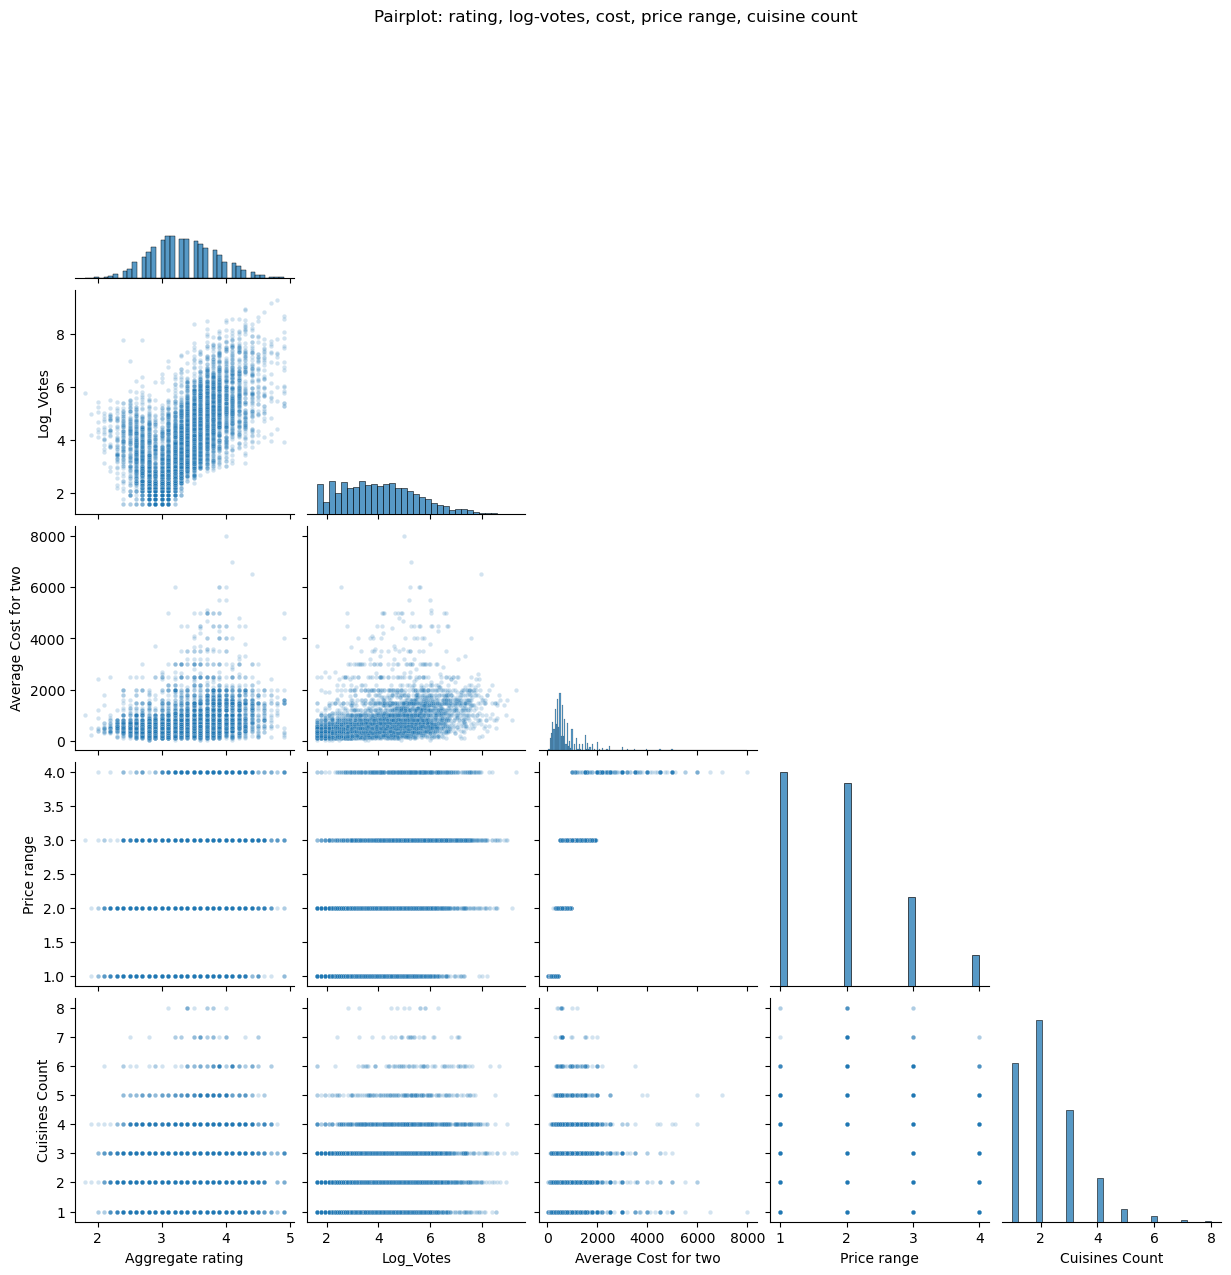

In [22]:
# Pairplot: rating, log-votes, cost, price range, cuisine count
sns.pairplot(df_rated[corr_cols], corner=True, plot_kws={'alpha': 0.2, 's': 10})
plt.suptitle('Pairplot: rating, log-votes, cost, price range, cuisine count', y=1.02)
plt.show()

### Observation:
The pairplot mostly confirms the heatmap numbers visually rather than revealing anything new: the rating/log-votes and cost/price-range panels show the tightest, most linear-looking clouds; every other pair looks diffuse. `Price range`'s panels show its usual banded/discrete pattern (it only takes 4 values) rather than a continuous scatter - worth remembering when reading any panel involving it, since a banded variable can look more/less correlated by eye than the correlation coefficient alone suggests.

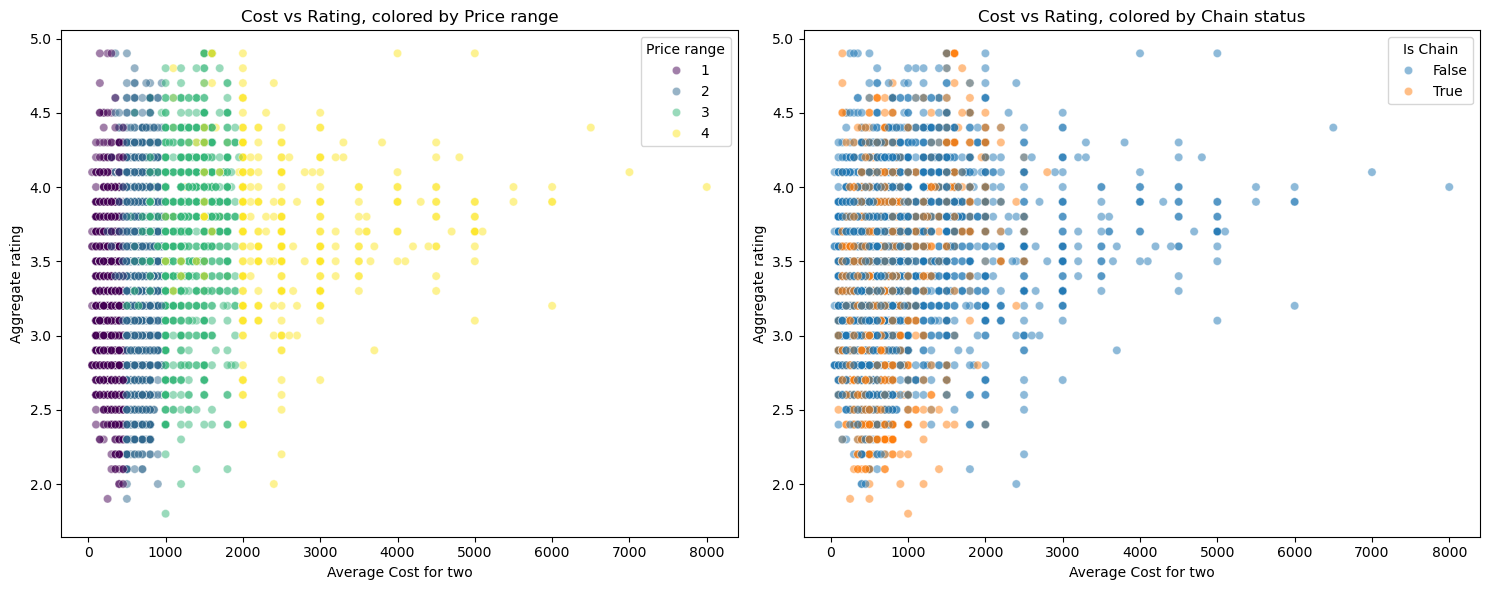

In [23]:
# Cost vs Rating, colored by Price range and by Chain status
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x='Average Cost for two', y='Aggregate rating', hue='Price range',
                 data=df_rated, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Cost vs Rating, colored by Price range')

sns.scatterplot(x='Average Cost for two', y='Aggregate rating', hue='Is Chain',
                 data=df_rated, alpha=0.5, ax=axes[1])
axes[1].set_title('Cost vs Rating, colored by Chain status')
plt.tight_layout()
plt.show()

### Observation:
The `Price range` hue panel shows clean, mostly-vertical color bands (as expected, since price range is a discretized version of cost) - it doesn't add new information over cost alone, it just confirms the redundancy again visually. The `Is Chain` panel is more useful: chain and independent restaurants overlap heavily across the entire cost/rating space - there's no visible cluster where chains dominate a cost or rating region - which matches the earlier finding that chain status barely moves mean rating (3.30 vs 3.38).

NCR rated rows with valid GPS: 5695 of 5808 total NCR rated rows


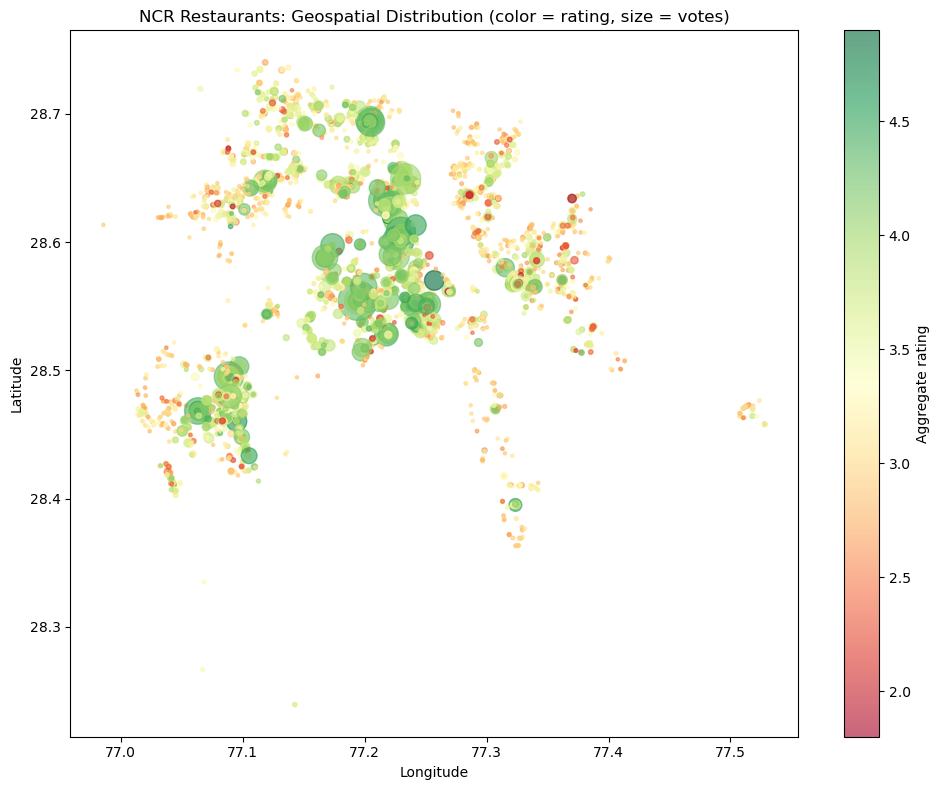

In [24]:
# Geospatial scatter of NCR restaurants, colored by rating, sized by votes
ncr_rated = df_rated[(df_rated['Is NCR']) & (df_rated['Latitude'] != 0) & (df_rated['Longitude'] != 0)]
print('NCR rated rows with valid GPS:', len(ncr_rated), 'of', df_rated['Is NCR'].sum(), 'total NCR rated rows')

plt.figure(figsize=(10, 8))
scatter = plt.scatter(ncr_rated['Longitude'], ncr_rated['Latitude'],
                       c=ncr_rated['Aggregate rating'], s=ncr_rated['Votes'] / 10 + 5,
                       cmap='RdYlGn', alpha=0.6)
plt.colorbar(scatter, label='Aggregate rating')
plt.title('NCR Restaurants: Geospatial Distribution (color = rating, size = votes)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Observation:
5,695 of 5,808 NCR rated restaurants (98%) have usable (non-zero) coordinates, so this map is representative, not a thin sample. Restaurants cluster into dense sub-pockets rather than spreading evenly across NCR - consistent with the earlier `Locality` finding that a handful of areas (Connaught Place, GK 1/2, Rajouri Garden...) concentrate much of the activity. There's no obvious single "green zone" of uniformly high ratings or "red zone" of uniformly low ones by eye - rating looks locally mixed within clusters rather than geographically segregated, which is exactly the kind of question the Phase 3.5 competition-density metric (`plan.md` §4.2, restaurants within 1km via `BallTree`) is designed to answer more rigorously than a scatter plot can.